#FOLder

In [6]:
!pip install librosa ripser persim scipy matplotlib


Enter path (ZIP / MP3 / WAV): /content/song5.mp3

Processing single file...



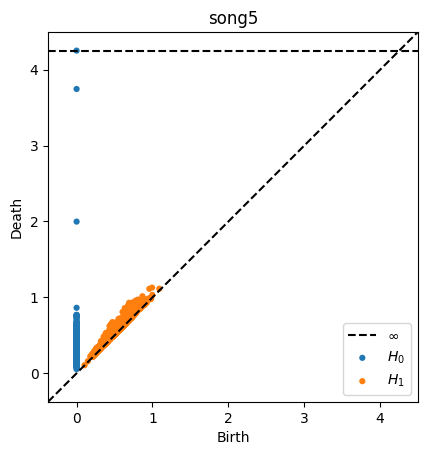

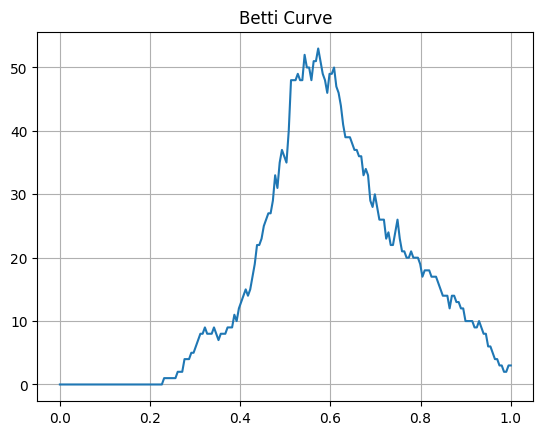


✅ SINGLE FILE DONE


In [8]:


import os
import zipfile
import numpy as nph
import librosa
import matplotlib.pyplot as plt
import pandas as pd
import math
import seaborn as sns

from ripser import ripser
from persim import plot_diagrams, wasserstein, PersistenceImager
from matplotlib.backends.backend_pdf import PdfPages


# ==============================
# FUNCTIONS
# ==============================

def extract_mfcc_pointcloud(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=22050, duration=30)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = (mfcc - np.mean(mfcc)) / np.std(mfcc)
    return mfcc.T


def compute_pd(point_cloud):
    return ripser(point_cloud, maxdim=1)['dgms']


def clean_h1(diagram, threshold=0.05):
    if len(diagram) == 0:
        return diagram
    return diagram[(diagram[:, 1] - diagram[:, 0]) > threshold]


def betti_curve(diagram, eps_values):
    curve = []
    for eps in eps_values:
        count = 0
        for birth, death in diagram:
            if birth <= eps < death:
                count += 1
        curve.append(count)
    return np.array(curve)


# ==============================
# MAIN
# ==============================

input_path = input("Enter path (ZIP / MP3 / WAV): ")

if not os.path.exists(input_path):
    raise Exception("File not found")

base_name = os.path.splitext(os.path.basename(input_path))[0]
output_root = f"output_{base_name}"
os.makedirs(output_root, exist_ok=True)


# ==============================
# CASE 1: ZIP FILE
# ==============================

if input_path.lower().endswith(".zip"):

    extract_folder = f"extracted_{base_name}"

    if not os.path.exists(extract_folder):
        os.makedirs(extract_folder)
        with zipfile.ZipFile(input_path, 'r') as z:
            z.extractall(extract_folder)

    songs = []
    for root, dirs, files in os.walk(extract_folder):
        for f in files:
            if f.lower().endswith((".mp3", ".wav")):
                songs.append(os.path.join(root, f))

    songs.sort()

    if len(songs) == 0:
        raise Exception("No audio files found")

    song_names = [os.path.splitext(os.path.basename(s))[0] for s in songs]

    print("\nProcessing songs...\n")

    pds = []
    h1_diagrams = []

    for song in songs:
        print("→", song)

        pc = extract_mfcc_pointcloud(song)
        diagram = compute_pd(pc)
        h1 = clean_h1(diagram[1])

        pds.append(diagram)
        h1_diagrams.append(h1)

    # ==============================
    # 1. PD PDF (FIXED)
    # ==============================

    pdf_file = f"{output_root}/{base_name}_PDs.pdf"
    plots_per_page = 6

    with PdfPages(pdf_file) as pdf:

        for k in range(0, len(pds), plots_per_page):

            fig, axes = plt.subplots(3, 2, figsize=(12, 12))
            axes = axes.flatten()

            for i in range(plots_per_page):
                idx = k + i

                if idx < len(pds):
                    plot_diagrams(pds[idx], ax=axes[i])
                    axes[i].set_title(song_names[idx], fontsize=8)
                else:
                    axes[i].axis('off')

            plt.tight_layout()
            pdf.savefig(fig)
            plt.close(fig)

    # ==============================
    # 2. WASSERSTEIN
    # ==============================

    n = len(songs)
    M = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            if i <= j:
                d = wasserstein(h1_diagrams[i], h1_diagrams[j])
                M[i][j] = d
                M[j][i] = d

    df_wass = pd.DataFrame(M, index=song_names, columns=song_names)
    df_wass.to_csv(f"{output_root}/{base_name}_wasserstein.csv")

    plt.figure(figsize=(10, 8))
    sns.heatmap(M, xticklabels=song_names, yticklabels=song_names,
                annot=True, fmt=".2f", cmap="viridis")

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"{output_root}/{base_name}_wasserstein.png")
    plt.show()

    values = [M[i][j] for i in range(n) for j in range(i+1, n)]
    avg = np.mean(values)

    with open(f"{output_root}/{base_name}_wasserstein_avg.txt", "w") as f:
        f.write(str(avg))

    # ==============================
    # 3. BETTI
    # ==============================

    eps_values = np.linspace(0, 1, 200)
    betti_data = []

    plt.figure(figsize=(12, 6))
    colors = plt.cm.tab20(np.linspace(0, 1, len(h1_diagrams)))

    for i in range(len(h1_diagrams)):
        curve = betti_curve(h1_diagrams[i], eps_values)
        betti_data.append(curve)
        plt.plot(eps_values, curve, color=colors[i], label=song_names[i])

    df_betti = pd.DataFrame(betti_data, index=song_names,
                            columns=np.round(eps_values, 4))
    df_betti.to_csv(f"{output_root}/{base_name}_betti.csv")

    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)
    plt.xlabel("ε")
    plt.ylabel("Betti-1")
    plt.title("Betti Curves")
    plt.grid()

    plt.tight_layout()
    plt.savefig(f"{output_root}/{base_name}_betti.png")
    plt.show()

    # ==============================
    # 4. PI
    # ==============================

    pimgr = PersistenceImager(pixel_size=0.02)
    pimgr.fit(h1_diagrams)

    pi_vectors = []

    for i, diagram in enumerate(h1_diagrams):

        if len(diagram) == 0:
            img = np.zeros((50, 50))
        else:
            img = pimgr.transform(diagram)

        pi_vectors.append(img.flatten())

        plt.imshow(img, origin='lower', cmap='viridis')
        plt.colorbar()
        plt.title(song_names[i])

        plt.savefig(f"{output_root}/{song_names[i]}_PI.png")
        plt.close()

    df_pi = pd.DataFrame(pi_vectors, index=song_names)
    df_pi.to_csv(f"{output_root}/{base_name}_PI.csv")

    print("\n✅ ZIP DONE")


# ==============================
# CASE 2: SINGLE FILE
# ==============================

elif input_path.lower().endswith((".mp3", ".wav")):

    song_name = base_name

    print("\nProcessing single file...\n")

    pc = extract_mfcc_pointcloud(input_path)
    diagram = compute_pd(pc)
    h1 = clean_h1(diagram[1])

    plt.figure()
    plot_diagrams(diagram)
    plt.title(song_name)
    plt.savefig(f"{output_root}/{song_name}_PD.png")
    plt.show()

    eps_values = np.linspace(0, 1, 200)
    curve = betti_curve(h1, eps_values)

    df_betti = pd.DataFrame([curve], index=[song_name],
                            columns=np.round(eps_values, 4))
    df_betti.to_csv(f"{output_root}/{song_name}_betti.csv")

    plt.plot(eps_values, curve)
    plt.title("Betti Curve")
    plt.grid()
    plt.savefig(f"{output_root}/{song_name}_betti.png")
    plt.show()

    pimgr = PersistenceImager(pixel_size=0.02)
    pimgr.fit([h1])

    img = pimgr.transform(h1) if len(h1) > 0 else np.zeros((50, 50))

    plt.imshow(img, origin='lower', cmap='viridis')
    plt.colorbar()
    plt.title(song_name)
    plt.savefig(f"{output_root}/{song_name}_PI.png")
    plt.close()

    df_pi = pd.DataFrame([img.flatten()], index=[song_name])
    df_pi.to_csv(f"{output_root}/{song_name}_PI.csv")

    print("\n✅ SINGLE FILE DONE")


else:
    raise Exception("Unsupported format")

##Clustering

Enter path of PI CSV file: /content/drive/MyDrive/Music /Observations /Clustering/merged_betti_songs.csv

Loaded data shape: (18, 200)

Checking for missing values...
Total NaNs in dataset: 0

Enter number of clusters (k): 3

Cluster assignments:

g1 → Cluster 0
g2 → Cluster 2
g3 → Cluster 0
g4 → Cluster 0
g5 → Cluster 2
g6 → Cluster 0
s1 → Cluster 0
s2 → Cluster 0
s3 → Cluster 0
s4 → Cluster 0
s5 → Cluster 0
s6 → Cluster 0
p1 → Cluster 1
p2 → Cluster 1
p3 → Cluster 1
p4 → Cluster 1
p5 → Cluster 1
p6 → Cluster 1

Saved clustering results to: clustered_results.csv
Saved PCA clustering results to: clustered_pca_results.csv


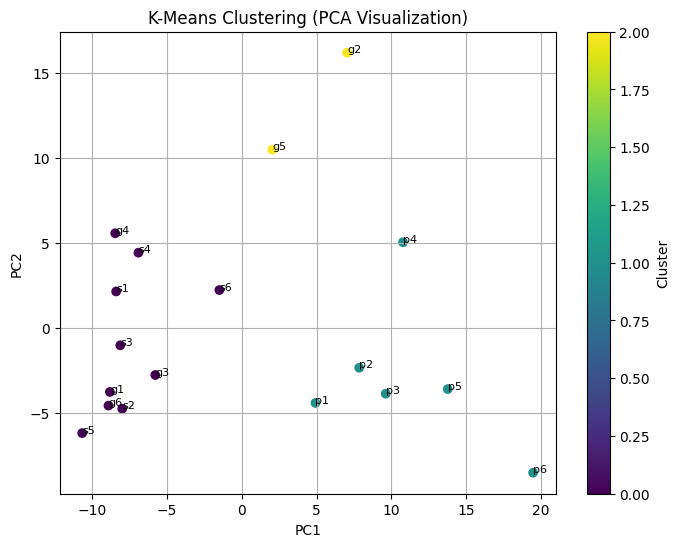

In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt


# ==============================
# INPUT
# ==============================
csv_path = input("Enter path of PI CSV file: ")

# Load data
df = pd.read_csv(csv_path, index_col=0)

print("\nLoaded data shape:", df.shape)


# ==============================
# CHECK FOR NaNs
# ==============================
print("\nChecking for missing values...")
nan_count = df.isna().sum().sum()
print("Total NaNs in dataset:", nan_count)

if nan_count > 0:
    print("\nRows with NaNs:\n")
    print(df[df.isna().any(axis=1)])


# ==============================
# PREPROCESSING
# ==============================
X = df.values

# Handle NaNs
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ==============================
# CHOOSE NUMBER OF CLUSTERS
# ==============================
k = int(input("\nEnter number of clusters (k): "))


# ==============================
# K-MEANS CLUSTERING
# ==============================
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)


# ==============================
# SAVE ORIGINAL CLUSTER RESULTS
# ==============================
df["Cluster"] = labels

print("\nCluster assignments:\n")
for song, cluster in zip(df.index, labels):
    print(f"{song} → Cluster {cluster}")

# Save original results
output_file = "clustered_results.csv"
df.to_csv(output_file)

print("\nSaved clustering results to:", output_file)


# ==============================
# PCA TRANSFORMATION
# ==============================
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(X_reduced, columns=["PC1", "PC2"], index=df.index)
pca_df["Cluster"] = labels

# Save PCA results
pca_output_file = "clustered_pca_results.csv"
pca_df.to_csv(pca_output_file)

print("Saved PCA clustering results to:", pca_output_file)


# ==============================
# PCA VISUALIZATION
# ==============================
plt.figure(figsize=(8, 6))

scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels)

# Annotate points
for i, name in enumerate(df.index):
    plt.text(X_reduced[i, 0], X_reduced[i, 1], name, fontsize=8)

plt.title("K-Means Clustering (PCA Visualization)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(scatter, label="Cluster")
plt.grid()

plt.savefig("cluster_plot.png", dpi=300, bbox_inches='tight')
plt.show()

## PREDICTION OF GENRE

In [ ]:
# ==============================
# IMPORTS
# ==============================
import numpy as np
import pandas as pd
import librosa

from ripser import ripser
from persim import PersistenceImager

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


# ==============================
# ===== TRAIN MODEL FIRST ======
# ==============================

# Load training data (your Betti CSVs)
ghazal = pd.read_csv("/content/drive/MyDrive/Music /Observations /Ghazals/Ghazals_final_betti_data.csv", index_col=0)
party  = pd.read_csv("/content/drive/MyDrive/Music /Observations /Party Songs/Party_final_betti_data.csv", index_col=0)
sad    = pd.read_csv("/content/drive/MyDrive/Music /Observations /Sad Songs/Sad_final_betti_data.csv", index_col=0)

# Labels
ghazal["label"] = "ghazal"
party["label"]  = "party"
sad["label"]    = "sad"

data = pd.concat([ghazal, party, sad])

X = data.drop(columns=["label"]).values
y = data["label"].values

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_scaled, y)


# ==============================
# ===== FEATURE PIPELINE =======
# ==============================

def extract_mfcc_pointcloud(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=22050, duration=30)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = (mfcc - np.mean(mfcc)) / np.std(mfcc)
    return mfcc.T


def compute_pd(point_cloud):
    return ripser(point_cloud, maxdim=1)['dgms']


def clean_h1(diagram, threshold=0.05):
    if len(diagram) == 0:
        return diagram
    return diagram[(diagram[:, 1] - diagram[:, 0]) > threshold]


def betti_curve(diagram, eps_values):
    curve = []
    for eps in eps_values:
        count = 0
        for birth, death in diagram:
            if birth <= eps < death:
                count += 1
        curve.append(count)
    return np.array(curve)


# ==============================
# ===== FINAL PREDICTION =======
# ==============================

def predict_genre_from_song(file_path):

    # Step 1: MFCC → point cloud
    pc = extract_mfcc_pointcloud(file_path)

    # Step 2: Persistence diagram
    diagram = compute_pd(pc)

    # Step 3: H1 cleaning
    h1 = clean_h1(diagram[1])

    # Step 4: Betti curve
    eps_values = np.linspace(0, 1, 200)
    curve = betti_curve(h1, eps_values)

    # Step 5: reshape + scale
    X_new = curve.reshape(1, -1)
    X_new = scaler.transform(X_new)

    # Step 6: prediction
    pred = model.predict(X_new)

    return pred[0]


# ==============================
# ===== USE IT LIKE THIS =======
# ==============================

song_path = input("Enter path of song (.mp3 or .wav): ")

genre = predict_genre_from_song(song_path)

print("🎵 Predicted Genre:", genre)